In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Set random seed
tf.random.set_seed(42)
np.random.seed(42)

# Dataset settings
vocab_size = 10000
max_length = 200

# Load IMDb dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Pad sequences to equal length
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training samples: 25000
Testing samples: 25000
Training shape: (25000, 200)
Testing shape: (25000, 200)


In [5]:
# Create RNN model
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),

    SimpleRNN(64),

    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.5008 - loss: 0.6950 - val_accuracy: 0.5050 - val_loss: 0.6935
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.5393 - loss: 0.6886 - val_accuracy: 0.5028 - val_loss: 0.6938
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.5794 - loss: 0.6667 - val_accuracy: 0.5056 - val_loss: 0.7081


Test Loss: 0.7070256471633911
Test Accuracy: 0.5022799968719482
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.77      0.61     12500
    Positive       0.50      0.23      0.32     12500

    accuracy                           0.50     25000
   macro avg       0.50      0.50      0.46     25000
weighted avg       0.50      0.50      0.46     25000



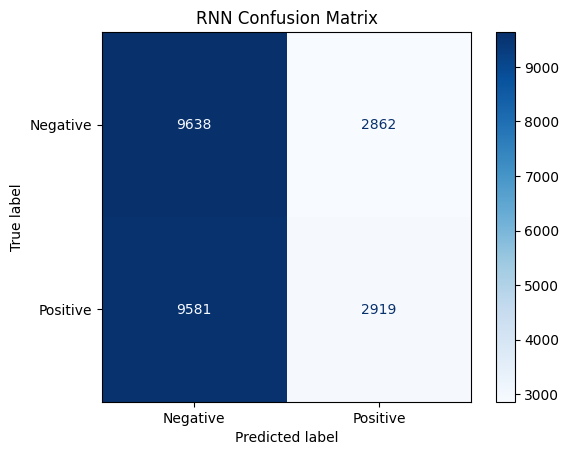

In [6]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Make predictions
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int).ravel()

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues")
plt.title("RNN Confusion Matrix")
plt.show()

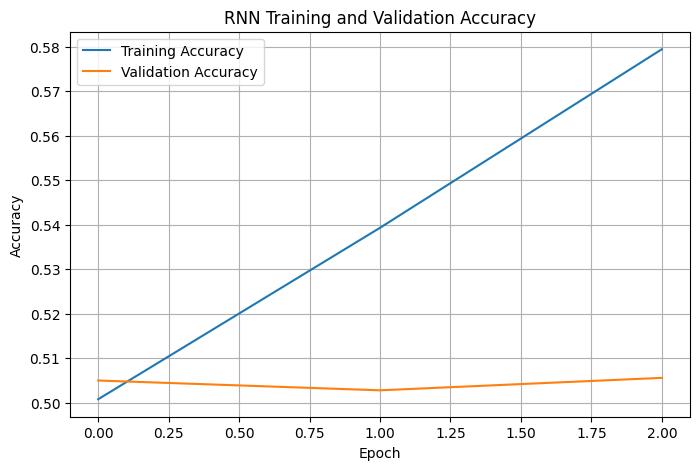

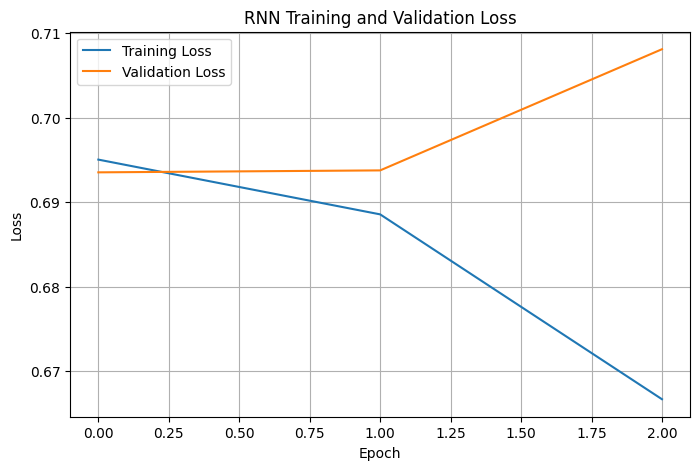

In [7]:
# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()